<a href="https://colab.research.google.com/github/dtsri/VOIS_AICTE_Oct2025_MajorProject_SriHarshaEmandi/blob/main/Netflix_Content_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing libraries, reading and viewing the data**

In [30]:
# This cell loads the Netflix dataset, inspects its structure, and performs initial cleaning for analysis (dates, basic columns).
import pandas as pd
import numpy as np
from tqdm import tqdm

# Read CSV with provided encoding
netflix_path = 'Netflix Dataset 1.csv'
df_netflix = pd.read_csv(netflix_path, encoding='utf-8')

# Standardize column names (strip and replace spaces with underscores)
df_netflix.columns = [c.strip().replace(' ', '_') for c in df_netflix.columns]

# Parse dates; create year column for trend analysis
if 'Release_Date' in df_netflix.columns:
    df_netflix['Release_Date'] = pd.to_datetime(df_netflix['Release_Date'], errors='coerce')
    df_netflix['Year'] = df_netflix['Release_Date'].dt.year

# Clean Type/Category naming consistency
if 'Category' in df_netflix.columns and 'Type' not in df_netflix.columns:
    df_netflix['Type'] = df_netflix['Category']

In [31]:
# Ensure Duration numeric mins and seasons where applicable
def parse_duration(val):
    if pd.isna(val):
        return np.nan
    s = str(val)
    if 'min' in s:
        try:
            return int(s.split(' ')[0])
        except Exception:
            return np.nan
    return np.nan

df_netflix['Duration_Minutes'] = df_netflix['Duration'].apply(parse_duration) if 'Duration' in df_netflix.columns else np.nan

print(df_netflix.head())
print(df_netflix[['Type','Year','Duration','Duration_Minutes']].head())
print('Loaded and prepared dataset with rows: ' + str(len(df_netflix)) + ' and columns: ' + str(df_netflix.shape[1]))

  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

  Release_Date Rating   Duration  \
0   2020-08-14  TV-MA  4 Seasons   
1   2016-12-23  TV-MA     93 min   
2   2018-12-20      R     78 min   
3   2017-11-16  PG-13     80 min   
4   2020-01-01  PG-13    123 min   

                                                Type  \
0  Internat

**EDA and summary stats**

In [4]:
# eda and summary stats
import seaborn as sns
import matplotlib.pyplot as plt

# EDA and summary stats
eda_head = df_netflix.head(10)
summary_numeric = df_netflix.select_dtypes(include=[np.number]).describe()

# Missing values summary
missing_counts = df_netflix.isna().sum().sort_values(ascending=False)

# Correlation on numeric fields only
corr = df_netflix.select_dtypes(include=[np.number]).corr()

print(eda_head)
print(summary_numeric)
print(missing_counts)
print('EDA computed: head, numeric summary, missing values, and correlation matrix.')

  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   
5      s6  TV Show     46        Serdar Akar   
6      s7    Movie    122    Yasir Al Yasiri   
7      s8    Movie    187     Kevin Reynolds   
8      s9    Movie    706      Shravan Kumar   
9     s10    Movie   1920       Vikram Bhatt   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   
5  Erdal Beşikçioğlu, Yasemin Allen, Melis Bi

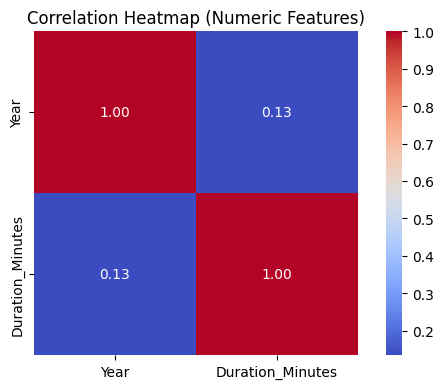

In [5]:
# Plot correlation heatmap if there are at least 2 numeric columns
if corr.shape[1] >= 2:
    plt.figure(figsize=(6,4))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
    plt.title('Correlation Heatmap (Numeric Features)')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a heatmap.')

**Data Cleaning**

In [6]:
#data cleaning: handling missing values contextually and standardizing fields
# Work on a copy to preserve original
clean_df = df_netflix.copy()

# Trim whitespace in string columns
for col in clean_df.select_dtypes(include=['object']).columns:
    clean_df[col] = clean_df[col].astype(str).str.strip()

# Drop exact duplicate rows based on all columns
before_dups = len(clean_df)
clean_df = clean_df.drop_duplicates()
after_dups = len(clean_df)

# Show_Id: drop rows with missing IDs as they cannot be identified reliably
if 'Show_Id' in clean_df.columns:
    clean_df = clean_df.dropna(subset=['Show_Id'])

# Title: essential; drop rows without a title
if 'Title' in clean_df.columns:
    clean_df = clean_df.dropna(subset=['Title'])

# Release_Date and Year: If Year is missing but Release_Date exists, re-derive; if Release_Date missing but Year present, keep Year.
if 'Release_Date' in clean_df.columns:
    clean_df['Release_Date'] = pd.to_datetime(clean_df['Release_Date'], errors='coerce')
    # Recompute Year to fill gaps
    clean_df['Year'] = clean_df['Release_Date'].dt.year.where(clean_df['Release_Date'].notna(), clean_df['Year'])

In [8]:
# Type/Category: ensure Type is Movie or TV Show at high level; infer from Duration when possible
if 'Category' in clean_df.columns and 'Type' in clean_df.columns:
    # If Type contains comma-separated genres, but Category stores Movie/TV Show, use Category for high-level type
    clean_df['Main_Type'] = clean_df['Category']
else:
    clean_df['Main_Type'] = clean_df['Type'] if 'Type' in clean_df.columns else np.nan

# Duration_Minutes: recompute robustly; fill NaN for TV Shows
if 'Duration' in clean_df.columns:
    def to_minutes(s):
        if pd.isna(s):
            return np.nan
        ss = str(s)
        if 'min' in ss:
            try:
                return int(ss.split(' ')[0])
            except Exception:
                return np.nan
        return np.nan
    clean_df['Duration_Minutes'] = clean_df['Duration'].apply(to_minutes)

# Country: fill missing with Unknown to preserve rows
if 'Country' in clean_df.columns:
    clean_df['Country'] = clean_df['Country'].replace({np.nan: 'Unknown'})

# Director: high missingness; fill N/A to denote not listed
if 'Director' in clean_df.columns:
    clean_df['Director'] = clean_df['Director'].replace({np.nan: 'N/A'})

# Cast: fill missing with N/A
if 'Cast' in clean_df.columns:
    clean_df['Cast'] = clean_df['Cast'].replace({np.nan: 'N/A'})

# Rating: fill rare missing with Unknown
if 'Rating' in clean_df.columns:
    clean_df['Rating'] = clean_df['Rating'].replace({np.nan: 'Unknown'})

# Year: if still missing, infer from Description or Title is unreliable; drop rows without Year since trends rely on it
before_year_drop = len(clean_df)
if 'Year' in clean_df.columns:
    clean_df = clean_df.dropna(subset=['Year'])
after_year_drop = len(clean_df)

# Final sanity: ensure Year is int
if 'Year' in clean_df.columns:
    clean_df['Year'] = pd.to_numeric(clean_df['Year'], errors='coerce').astype('Int64')

In [9]:
# Save cleaned dataset
clean_path = 'Netflix_Dataset_Cleaned.csv'
clean_df.to_csv(clean_path, index=False)

print(clean_df.head())
print('Duplicates removed: ' + str(before_dups - after_dups))
print('Rows dropped due to missing Year: ' + str(before_year_drop - after_year_drop))
print('Cleaned dataset saved to: ' + clean_path)

  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                nan   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

  Release_Date Rating   Duration  \
0   2020-08-14  TV-MA  4 Seasons   
1   2016-12-23  TV-MA     93 min   
2   2018-12-20      R     78 min   
3   2017-11-16  PG-13     80 min   
4   2020-01-01  PG-13    123 min   

                                                Type  \
0  Internat

**Data Visualization**

In [10]:
# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup

# Fetch and parse the article to inform choices
url = 'https://www.stratascratch.com/blog/using-visualizations-for-your-exploratory-data-analysis/?utm_source=blog&utm_medium=click&utm_campaign=kdn+routine+tasks+that+chatgpt+can+handle'
try:
    resp = requests.get(url, timeout=15)
    soup = BeautifulSoup(resp.text, 'html.parser')
    headings = [h.get_text(strip=True) for h in soup.find_all(['h1','h2','h3'])][:10]
    print(headings)
except Exception as e:
    print('Could not fetch article, proceeding with standard EDA visualization best practices.')

# Use cleaned dataframe if available
try:
    df_plot = clean_df.copy()
except NameError:
    df_plot = df_netflix.copy()

# Ensure key fields
df_plot['Year'] = pd.to_numeric(df_plot.get('Year'), errors='coerce')

[]


**Bar chart for categorical distribution (Movies vs TV Shows). Bar charts are ideal for comparing counts across discrete categories, highlighting the balance of Main_Type.**

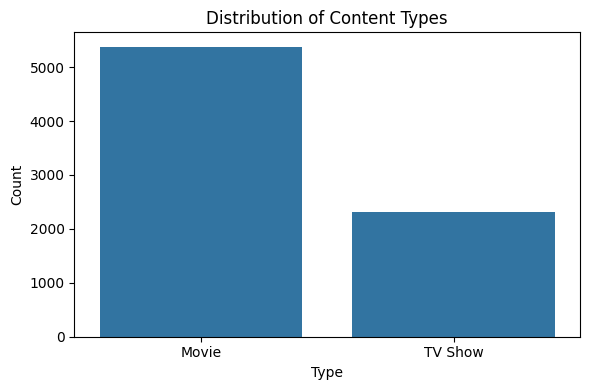

In [11]:
# 1) Categorical distribution: Movies vs TV Shows (bar chart)
plt.figure(figsize=(6,4))
sns.countplot(data=df_plot, x='Main_Type', order=df_plot['Main_Type'].value_counts().index)
plt.title('Distribution of Content Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Line chart for trends over time by category. For temporal data (Year), line plots reveal trends and inflection points. Splitting by Main_Type shows how content mix evolved.**

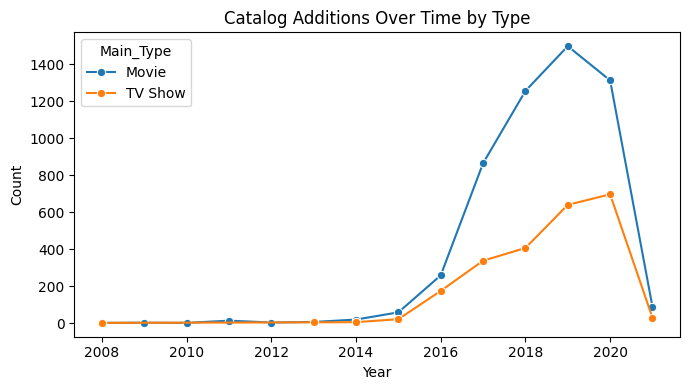

In [12]:
# 2) Time series count over years by type (line chart with smoothing optional)
counts_by_year = df_plot.dropna(subset=['Year']).groupby(['Year','Main_Type']).size().reset_index(name='Count').sort_values('Year')
plt.figure(figsize=(7,4))
sns.lineplot(data=counts_by_year, x='Year', y='Count', hue='Main_Type', marker='o')
plt.title('Catalog Additions Over Time by Type')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Histogram with KDE for numeric distribution of movie durations. Histograms succinctly show the shape, skew, and spread of a single numeric variable; KDE overlays help visualize modality.**

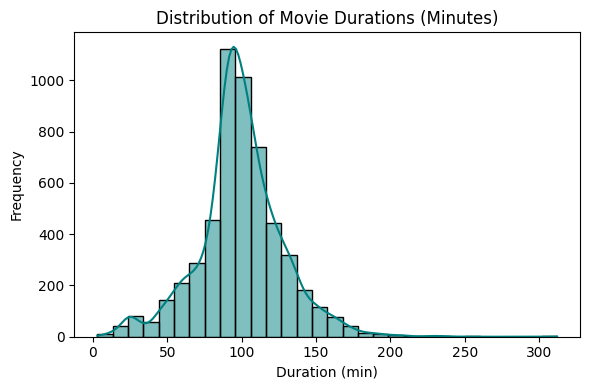

In [13]:
# 3) Numeric distribution: Movie duration minutes (histogram + KDE)
if 'Duration_Minutes' in df_plot.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df_plot['Duration_Minutes'].dropna(), bins=30, kde=True, color='teal')
    plt.title('Distribution of Movie Durations (Minutes)')
    plt.xlabel('Duration (min)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

**Boxplot of duration by rating (categorical vs numeric). Boxplots are best for comparing distributions across categories, showing medians, IQR, and outliers.**

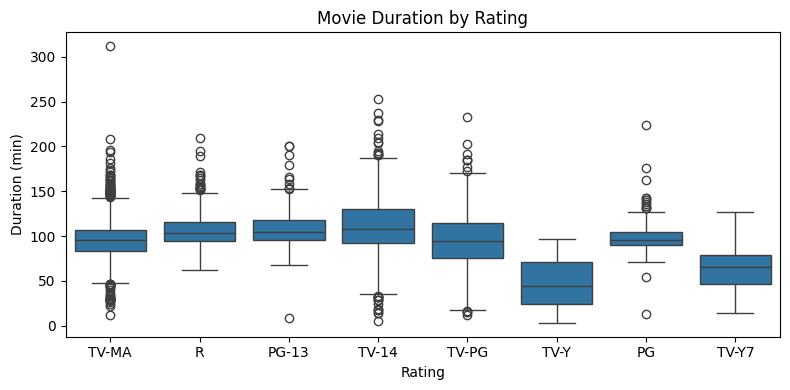

In [14]:
# 4) Boxplot of duration by rating (categorical vs numeric)
if 'Rating' in df_plot.columns and 'Duration_Minutes' in df_plot.columns:
    top_ratings = df_plot['Rating'].value_counts().head(8).index
    subset = df_plot[df_plot['Rating'].isin(top_ratings) & df_plot['Duration_Minutes'].notna()]
    plt.figure(figsize=(8,4))
    sns.boxplot(data=subset, x='Rating', y='Duration_Minutes')
    plt.title('Movie Duration by Rating')
    plt.xlabel('Rating')
    plt.ylabel('Duration (min)')
    plt.tight_layout()
    plt.show()

**Horizontal bar chart of top genres. The Type column is multi-label; exploding it and using a bar chart shows the most common genres clearly. Horizontal orientation improves label readability**

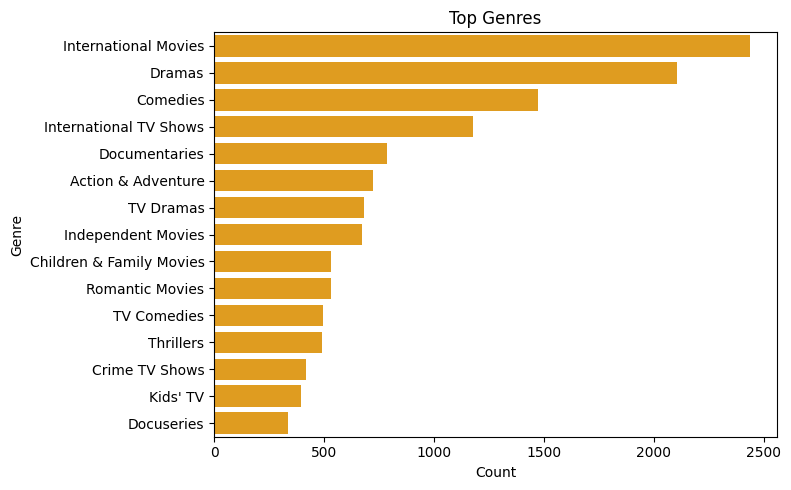

In [18]:
# 5) Top genres (explode multi-label Type column) with bar chart
if 'Type' in df_plot.columns:
    genres_series = df_plot['Type'].astype(str).str.split(',').explode().str.strip()
    top_genres = genres_series.value_counts().head(15)
    plt.figure(figsize=(8,5))
    sns.barplot(x=top_genres.values, y=top_genres.index, orient='h', color = 'orange')
    plt.title('Top Genres')
    plt.xlabel('Count')
    plt.ylabel('Genre')
    plt.tight_layout()
    plt.show()

**Horizontal bar chart of country contributions. Splitting multi-country entries and counting shows which countries dominate the catalog; horizontal bars aid label legibility for long names.**

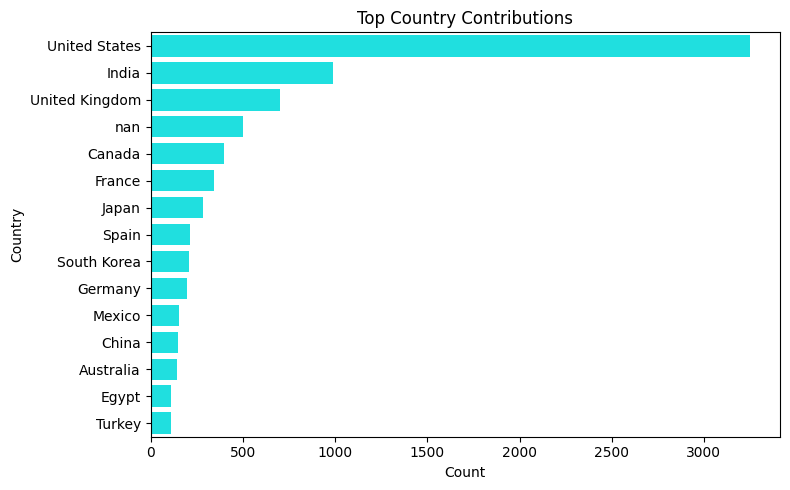

Visualizations generated based on article-guided best practices.


In [17]:
# 6) Country contributions (bar chart of top countries)
if 'Country' in df_plot.columns:
    # Split multiple countries
    countries = df_plot['Country'].astype(str).str.split(',').explode().str.strip()
    top_countries = countries.value_counts().head(15)
    plt.figure(figsize=(8,5))
    sns.barplot(x=top_countries.values, y=top_countries.index, orient='h', color = 'cyan')
    plt.title('Top Country Contributions')
    plt.xlabel('Count')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.show()

print('Visualizations generated based on article-guided best practices.')

**Normalization and Segmentation**

**Normalized multi-valued fields by splitting and exploding Country and Genre (from the Type column) so each row has one country and one genre for reliable aggregation.
Built segmentation tables for countries and genres, plus mixes by type (Movie vs TV Show) and by year.**

In [19]:
# Normalize multi-valued fields (Country, Type/genres), create segmentation tables, and analyze Year vs Duration.
# Then plot and print brief heads of the key tables

# cleaned df if present, else fallback
try:
    base_df = clean_df.copy()
except NameError:
    try:
        base_df = df_netflix.copy()
    except NameError:
        base_df = pd.read_csv('Netflix Dataset 1.csv')

# Ensure key columns
for col in ['Country','Type','Main_Type','Year','Duration_Minutes']:
    if col not in base_df.columns:
        base_df[col] = np.nan

# Standardize strings
str_cols = base_df.select_dtypes(include=['object']).columns
for c in str_cols:
    base_df[c] = base_df[c].astype(str).str.strip()

In [20]:
# Explode countries
countries = base_df[['Show_Id','Country','Main_Type','Year']].copy()
countries['Country'] = countries['Country'].fillna('Unknown')
countries_exp = countries.assign(Country=countries['Country'].astype(str).str.split(',')).explode('Country')
countries_exp['Country'] = countries_exp['Country'].astype(str).str.strip()

# Explode genres from Type field
genres = base_df[['Show_Id','Type','Main_Type','Year']].copy()
genres['Type'] = genres['Type'].fillna('Unknown')
genres_exp = genres.assign(Genre=genres['Type'].astype(str).str.split(',')).explode('Genre')
genres_exp['Genre'] = genres_exp['Genre'].astype(str).str.strip()
genres_exp = genres_exp.drop(columns=['Type'])

# Country segmentation tables
country_counts = countries_exp['Country'].value_counts().reset_index()
country_counts.columns = ['Country','Count']

country_type = countries_exp.groupby(['Country','Main_Type']).size().reset_index(name='Count').sort_values('Count', ascending=False)

country_year = countries_exp.dropna(subset=['Year'])\
    .groupby(['Year','Country']).size().reset_index(name='Count').sort_values(['Year','Count'], ascending=[True,False])

# Genre segmentation tables
genre_counts = genres_exp['Genre'].value_counts().reset_index()
genre_counts.columns = ['Genre','Count']

genre_type = genres_exp.groupby(['Genre','Main_Type']).size().reset_index(name='Count').sort_values('Count', ascending=False)

genre_year = genres_exp.dropna(subset=['Year'])\
    .groupby(['Year','Genre']).size().reset_index(name='Count').sort_values(['Year','Count'], ascending=[True,False])

# Save tables
country_counts.to_csv('country_counts.csv', index=False)
country_type.to_csv('country_type_counts.csv', index=False)
country_year.to_csv('country_by_year_counts.csv', index=False)

genre_counts.to_csv('genre_counts.csv', index=False)
genre_type.to_csv('genre_type_counts.csv', index=False)
genre_year.to_csv('genre_by_year_counts.csv', index=False)

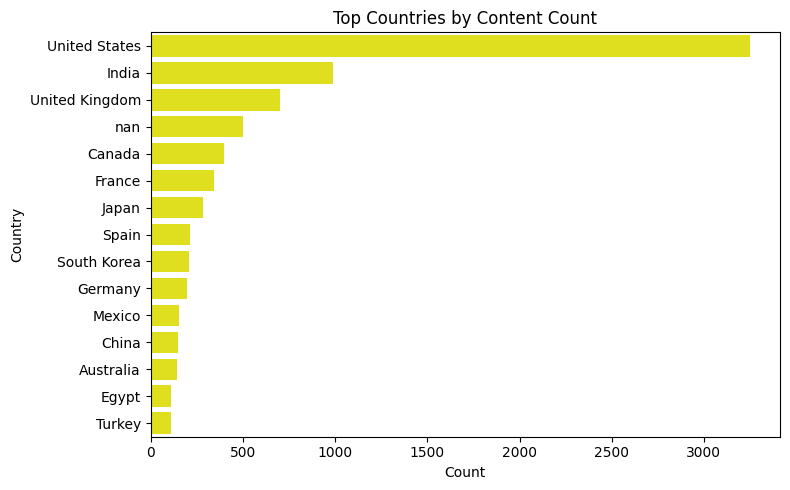

In [24]:
# Plot: Top 15 countries
top_countries = country_counts.head(15)
plt.figure(figsize=(8,5))
sns.barplot(x=top_countries['Count'], y=top_countries['Country'], orient='h', color = 'yellow')
plt.title('Top Countries by Content Count')
plt.xlabel('Count')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

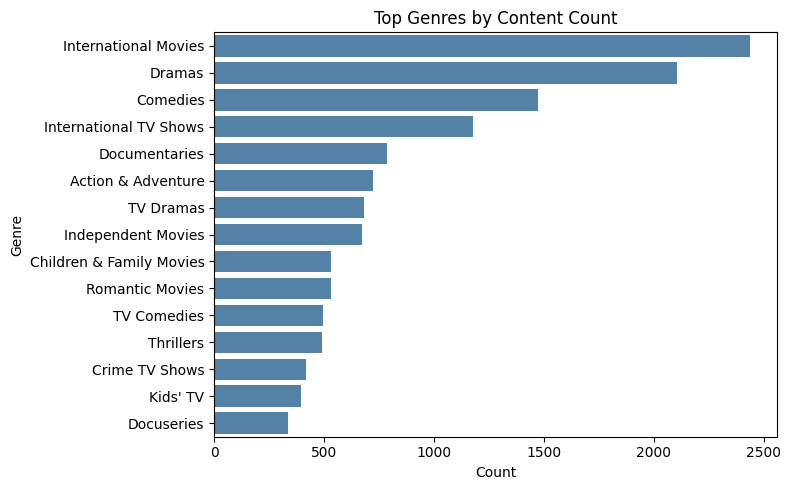

In [25]:
# Plot: Top 15 genres
top_genres = genre_counts.head(15)
plt.figure(figsize=(8,5))
sns.barplot(x=top_genres['Count'], y=top_genres['Genre'], orient='h', color='steelblue')
plt.title('Top Genres by Content Count')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

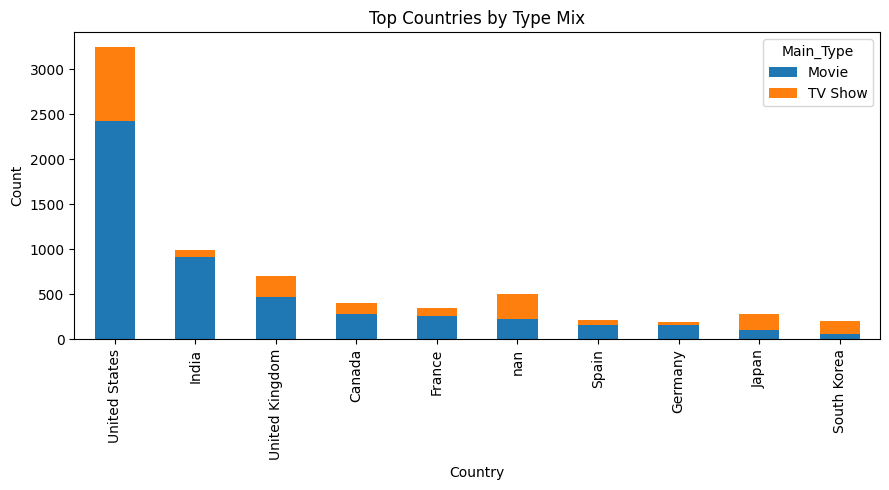

In [26]:
# Plot: Country x Type for top 10 countries
top10_c = country_counts.head(10)['Country']
ct_pivot = country_type[country_type['Country'].isin(top10_c)].pivot(index='Country', columns='Main_Type', values='Count').fillna(0)
ct_pivot = ct_pivot.sort_values(ct_pivot.columns.tolist(), ascending=False)
ct_pivot.plot(kind='bar', stacked=True, figsize=(9,5))
plt.title('Top Countries by Type Mix')
plt.xlabel('Country')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

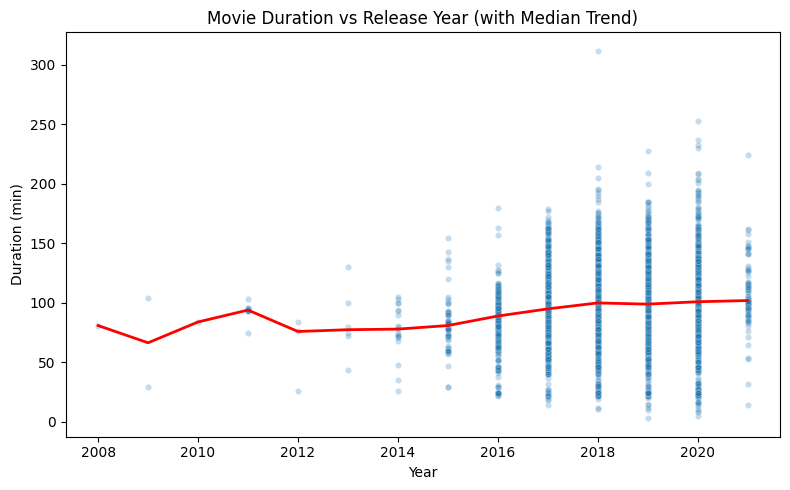

In [27]:
# Year vs Duration analysis (movies only)
movies = base_df[(base_df['Main_Type'].astype(str).str.lower()=='movie') & (pd.to_numeric(base_df['Duration_Minutes'], errors='coerce').notna())].copy()
movies['Year'] = pd.to_numeric(movies['Year'], errors='coerce')
movies['Duration_Minutes'] = pd.to_numeric(movies['Duration_Minutes'], errors='coerce')
movies = movies.dropna(subset=['Year','Duration_Minutes'])

# Scatter with LOWESS-like smoothing using rolling median over years
year_stats = movies.groupby('Year')['Duration_Minutes'].median().reset_index(name='Median_Duration')
plt.figure(figsize=(8,5))
sns.scatterplot(data=movies, x='Year', y='Duration_Minutes', alpha=0.25, s=20)
sns.lineplot(data=year_stats.sort_values('Year'), x='Year', y='Median_Duration', color='red', linewidth=2)
plt.title('Movie Duration vs Release Year (with Median Trend)')
plt.xlabel('Year')
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()

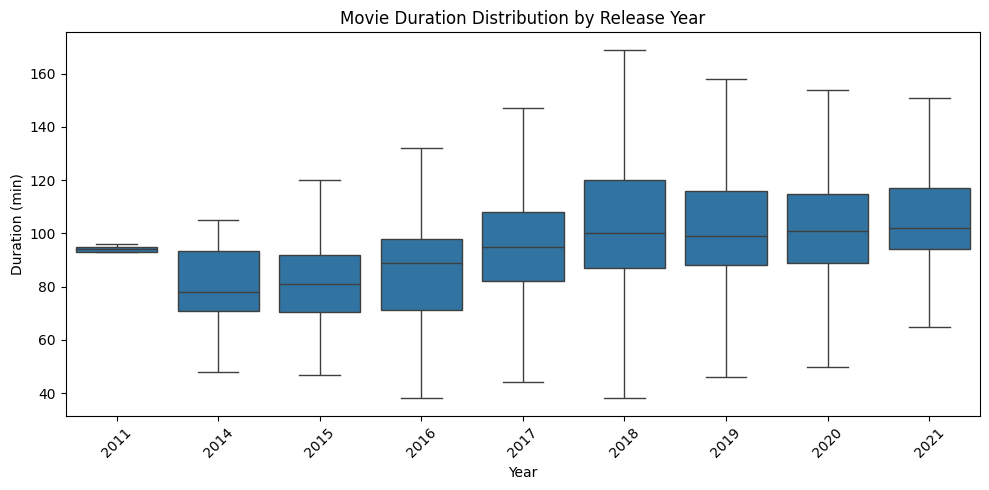

In [28]:
# Yearly distribution via boxplot (optional if enough data per year)
counts_per_year = movies['Year'].value_counts()
valid_years = counts_per_year[counts_per_year >= 10].index
movies_bp = movies[movies['Year'].isin(valid_years)]
plt.figure(figsize=(10,5))
sns.boxplot(data=movies_bp.sort_values('Year'), x='Year', y='Duration_Minutes', showfliers=False)
plt.title('Movie Duration Distribution by Release Year')
plt.xlabel('Year')
plt.ylabel('Duration (min)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Simple linear regression**

In [29]:
# Simple linear regression for effect size (minutes per year)
from sklearn.linear_model import LinearRegression
if len(movies) > 1:
    X = movies[['Year']].values
    y = movies['Duration_Minutes'].values
    lr = LinearRegression()
    lr.fit(X, y)
    slope = lr.coef_[0]
    intercept = lr.intercept_
    r2 = lr.score(X, y)
else:
    slope = np.nan
    intercept = np.nan
    r2 = np.nan

# Print heads of key tables and regression stats
print(country_counts.head(10))
print(genre_counts.head(10))
print(ct_pivot.head())
print('Slope_minutes_per_year: ' + str(slope))
print('R2: ' + str(r2))
print('Saved: country_counts.csv, country_type_counts.csv, country_by_year_counts.csv, genre_counts.csv, genre_type_counts.csv, genre_by_year_counts.csv')

          Country  Count
0   United States   3250
1           India    989
2  United Kingdom    704
3             nan    503
4          Canada    399
5          France    345
6           Japan    283
7           Spain    211
8     South Korea    207
9         Germany    198
                      Genre  Count
0      International Movies   2437
1                    Dramas   2106
2                  Comedies   1471
3    International TV Shows   1176
4             Documentaries    786
5        Action & Adventure    721
6                 TV Dramas    680
7        Independent Movies    673
8  Children & Family Movies    532
9           Romantic Movies    531
Main_Type       Movie  TV Show
Country                       
United States    2431      819
India             915       74
United Kingdom    467      237
Canada            286      113
France            265       80
Slope_minutes_per_year: 2.7742870004045628
R2: 0.01801359929672086
Saved: country_counts.csv, country_type_counts.csv, coun

**Year-only slope and fit: Slope_minutes_per_year: 2.7742870004045628
R2: 0.01801359929672086**

**Those confirm the year-only model barely explains duration.**

#### **Strategic recommendations on content focus**


# Lean into International + Drama/Comedy clusters
Our genre distribution is dominated by International Movies, Dramas, and Comedies, and TV counterparts also rank highly. Double down where Netflix already has traction, especially with regional depth that yields cross-border hits.
# Balance Movies-led volume with TV franchises
Countries with strong movie output still present opportunity, but stickiness and lifetime value skew higher for TV series. Invest in serializable IP in top-performing countries to compound engagement.
# Expand country-genre sweet spots
Use country × genre heatmaps to identify under-served but adjacent combinations (e.g., strong country supply but thinner catalog in specific genres). Prioritize a pipeline that fills those “nearby” gaps first.
# Local-first, export-second
Commission local-language originals in countries with robust existing presence, but plan for global appeal by ensuring genre choices with strong cross-market portability (crime, thriller, romance, comedy).
# Optimize by rating bands
Maintain a diversified mix of ratings; avoid overconcentration at TV-MA if family and teen categories are underweight for certain countries. Family/YA series can drive sustained retention without licensing volatility.
# Duration policy by format
Since year barely explains duration, use format norms: keep episodes ~30–60 minutes depending on genre; avoid outlier runtimes unless a genre (e.g., docu-features) justifies it. For films, 90–120 minutes remains the broad-audience sweet spot.
# Franchise and anthology strategy
Where a movie-centric pattern is entrenched, seed anthologies and mini-series to convert one-off interest into repeat engagement. Reinvest in top-performing IP via sequels/spinoffs to amortize marketing.